# Build a surrogate model in the same fashion as Du et al. for Actuator Position RL

Import required packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from joblib import dump, load
from datetime import datetime
import psutil
import os
from os import path
import time
import random
from typing import Optional
import tkinter as tk
from tkinter.messagebox import showinfo
import ansys
from ansys.mapdl.core import launch_mapdl
from ansys.mapdl import reader as mapdl_reader

In [8]:
st= time.time()

Build reusable code

In [9]:
class generateSurrogateData():
    def __init__(self):
        # Parse the Ansys input file
        #filepath = path.join(path.dirname(__file__),'Undeformed.inp')
        filepath = './SolutionInputUndeformed1.inp'
        self.ip = '129.161.91.97'
        with open(filepath, 'r') as f:
            text = f.read()
            new_text = text.split('/com,******************* SOLVE FOR LS 1 OF 1 ****************')
            self.setup_text = new_text[0]
            new_text = text.split('! *********** WB SOLVE COMMAND ***********')
            self.finish_text = new_text[1]
            f.close()

    def _launch_ansys(self):
        # Launch ANSYS

        self.mapdl = launch_mapdl(ip=self.ip, port=8800, loglevel='ERROR', override=True, cleanup_on_exit=True, nproc=4)
        print(self.mapdl)
        print("Running on", 4, "processors")


    def _set_actuator_forces(self, mapdl, forces):
        # Calculate y and z components of the forces from desired magnitudes
        angles = np.linspace(12, -192, 18)
        self.forces_Y = forces*np.cos(np.deg2rad(angles))
        self.forces_Z = forces*np.sin(np.deg2rad(angles))

        for i in range(0,18):
            # Set x component of force (practically zero)
            mapdl.esel("s", "real", "", 43+3*i)
            mapdl.sfe("all", 1, "pres", 1, 2.24808943074769e-009)
            # Set y component of force
            mapdl.esel("s", "real", "", 44+3*i)
            mapdl.sfe("all", 1, "pres", 1, self.forces_Y[i])
            # Set z component of force
            mapdl.esel("s", "real", "", 45+3*i)
            mapdl.sfe("all", 1, "pres", 1, self.forces_Z[i])
            
        mapdl.esel("all")   # make sure everything is selected before running solve 

        # Run the solution
        mapdl._run("/nopr")
        mapdl.run("/gopr")
        mapdl.run("nsub,1,1,1")
        mapdl.time(1.)
        mapdl.outres("erase")
        mapdl.outres("all", "none")
        mapdl.outres("nsol", "all")
        mapdl.outres("rsol", "all")
        mapdl.outres("eangl", "all")
        mapdl.outres("etmp", "all")
        mapdl.outres("veng", "all")
        mapdl.outres("strs", "all")
        mapdl.outres("epel", "all")
        mapdl.outres("eppl", "all")
        mapdl.outres("cont", "all")

    def _get_initPos(self):
        '''
        Get the initial positions of nodes on the fuselage edge before any forces are applied
        '''
        self.mapdl.cmsel(name='CM_FUSELAGE_EDGE') # select nodes on the edge of the fuselage
        initPos = self.mapdl.mesh.nodes # initial positions of nodes
        nnum = self.mapdl.mesh.nnum # corresponding node numbers
        self.mapdl.allsel()
        return initPos[:,1:3]    

    def _get_displacement(self):
        '''
        Get the displacement of nodes on the fuselage edge after forces have been applied. 
        The displacements are relative to the initial positions of the nodes.
        '''
        self.mapdl.cmsel(name='CM_FUSELAGE_EDGE') # select nodes on the edge of the fuselage
        displacements = self.mapdl.post_processing.nodal_displacement('ALL') # get displacements of nodes on the edge
        total = self.mapdl.post_processing.nodal_displacement('NORM')
        self.mapdl.allsel()
        return displacements[:,1:3], total

    def _monitor_process(self, processName):
        flag = False
        #Iterate over the all the running process
        for proc in psutil.process_iter():
            try:
                # Check if process name contains the given name string.
                if processName.lower() in proc.name().lower():
                    flag = True
            except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
                pass
        return flag

    def _run_ansys(self, forces):
        self.forces=forces       
        try:
            if not self._monitor_process('ansys'):
                self._launch_ansys()  
            # Clear solver memory
            self.mapdl.finish()
            self.mapdl.clear()
            #print("Ready to run")
            # Setup and run the simulation
            log1 = self.mapdl.input_strings(self.setup_text) # run setup
            log2 = self._set_actuator_forces(self.mapdl, self.forces) # apply forces
            log3 = self.mapdl.input_strings(self.finish_text) # complete solution
            self.result = self.mapdl.result # store result
            #print("Results are available")
        
        except:
            print("Exit Ansys and try to reconnect")
            
            try:
                self.mapdl.exit()
                print("Remote exit")
                time.sleep(10)
            except:
                print("No active Ansys process found. Wait and try to reconnect")
                time.sleep(10)
                
            i = 0
            while True:
                i += 1
                try: 
                    self._launch_ansys()
                    print("Sucessfully reconnected to Ansys on attempt", i)
                    print("Try running again")
                    log1 = self.mapdl.input_strings(self.setup_text) # run setup
                    print("Simulation setup complete")
                    log2 = self._set_actuator_forces(self.mapdl, self.forces) # apply forces
                    print("Applied forces")
                    log3 = self.mapdl.input_strings(self.finish_text) # complete solution
                    print("Solve finished")
                    self.result = self.mapdl.result # store result 
                    print("Results ready")         
                    
                    break

                except:
                    try:
                        print("Reconnect failed - remote exit again")
                        self.mapdl.exit()
                        time.sleep(10)
                    except:
                        time.sleep(10)
                        if i <=3:
                            print("Wait and try to reconnect again - attempt", i)
                        else:
                            print("Check Ansys license server connection")
                            # Create popup message
                            root = tk.Tk()
                            root.title('Warning')
                            root.geometry('300x150')
                            answer = showwarning(title='Warning',
                                                message='Check Ansys license server connection!')
                            if answer:
                                root.destroy()
                            time.sleep(5)
    
    def run(self, forces):
        self._run_ansys(forces)
        displacements, total = self._get_displacement()
        displacements = np.array(displacements, dtype=np.float32)
        total = np.array(total, dtype=np.float32)
        initPos = np.array(self._get_initPos(), dtype=np.float32)
        return displacements, total, initPos





Verify that generator runs properly

In [10]:
forces=  np.ones(18, dtype=np.float32)  * 10

generator = generateSurrogateData()
U, T, P = generator.run(forces)

Product:             Ansys Mechanical Enterprise Academic Student
MAPDL Version:       24.2
ansys.mapdl Version: 0.67.0

Running on 4 processors
Exit Ansys and try to reconnect
No active Ansys process found. Wait and try to reconnect
Product:             Ansys Mechanical Enterprise Academic Student
MAPDL Version:       24.2
ansys.mapdl Version: 0.67.0

Running on 4 processors
Sucessfully reconnected to Ansys on attempt 1
Try running again
Simulation setup complete
Applied forces
Solve finished
Reconnect failed - remote exit again
Wait and try to reconnect again - attempt 1
Product:             Ansys Mechanical Enterprise Academic Student
MAPDL Version:       24.2
ansys.mapdl Version: 0.67.0

Running on 4 processors
Sucessfully reconnected to Ansys on attempt 2
Try running again
Simulation setup complete
Applied forces
Solve finished
Reconnect failed - remote exit again
Wait and try to reconnect again - attempt 2
Product:             Ansys Mechanical Enterprise Academic Student
MAPDL Ve

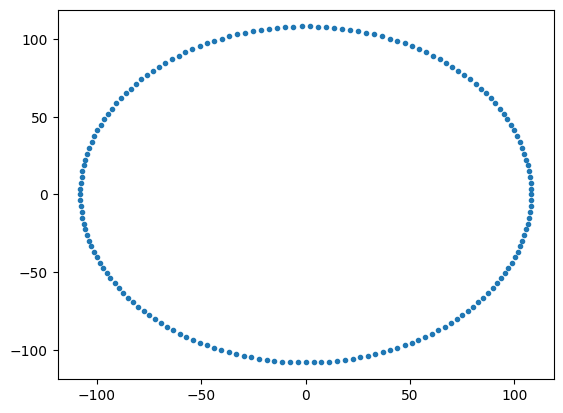

In [11]:
plt.plot(P[:,0],P[:,1],'.')


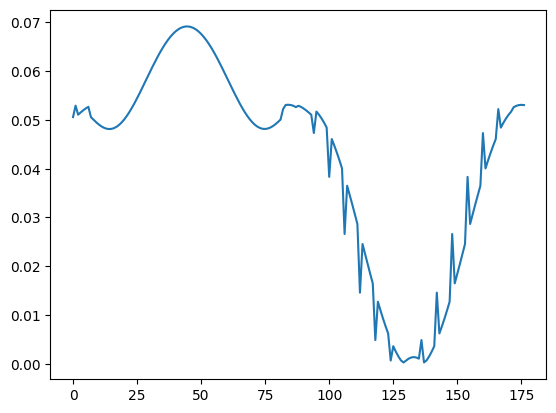

In [12]:
plt.plot(T[:])


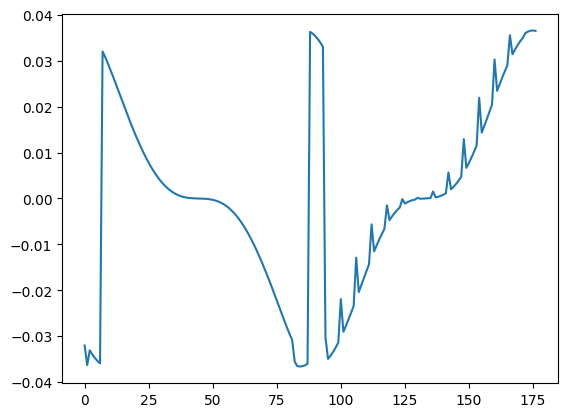

In [13]:
plt.plot(U[:,0])


In [14]:
print(generator.forces_Y)
print(generator.forces_Z)

[  9.78147601  10.           9.78147601   9.13545458   8.09016994
   6.69130606   5.           3.09016994   1.04528463  -1.04528463
  -3.09016994  -5.          -6.69130606  -8.09016994  -9.13545458
  -9.78147601 -10.          -9.78147601]
[ 2.07911691e+00  0.00000000e+00 -2.07911691e+00 -4.06736643e+00
 -5.87785252e+00 -7.43144825e+00 -8.66025404e+00 -9.51056516e+00
 -9.94521895e+00 -9.94521895e+00 -9.51056516e+00 -8.66025404e+00
 -7.43144825e+00 -5.87785252e+00 -4.06736643e+00 -2.07911691e+00
 -1.22464680e-15  2.07911691e+00]


Run with original input file from the first test sample to verify solution is as expected

In [16]:
filepath = './SolutionInputUndeformed1.inp'
with open(filepath, 'r') as f:
    text = f.read()
generator.mapdl.finish()
generator.mapdl.clear()
log = generator.mapdl.input_strings(text)

## Generate training and testing data for the surrogate model

Import training and testing forces from DOE

In [4]:
X_train = np.genfromtxt('X_train.csv', delimiter=',')
X_test = np.genfromtxt('X_test.csv', delimiter=',')
print(X_train[0,:])

(18,)


In [5]:
y_train = np.genfromtxt('y_train.csv', delimiter=',')
y_test = np.genfromtxt('y_test.csv', delimiter=',')
ytotal_train = np.genfromtxt('ytotal_train.csv', delimiter=',')
ytotal_test = np.genfromtxt('ytotal_test.csv', delimiter=',')


print(y_train[0,:].shape)

(354,)


In [ ]:
generator = generateSurrogateData()

# Generate training data
n= X_train.shape[0]
y_train = np.zeros([n, 177*2])
ytotal_train = np.zeros([n,177])
for i in range(n):
    U, T, P = generator.run(X_train[i,:])
    y_train[i,:]= U.flatten()
    ytotal_train[i,:] = T.flatten()

# Generate test data
n= X_test.shape[0]
y_test = np.zeros([n, 177*2])
ytotal_test = np.zeros([n,177])
for i in range(n):
    U, T, P = generator.run(X_test[i,:])
    y_test[i,:]= U.flatten()
    ytotal_test[i,:] = T.flatten()

# Save to .csv files
np.savetxt("y_train.csv", y_train, delimiter=",")
np.savetxt("y_test.csv", y_test, delimiter=",")
np.savetxt("ytotal_train.csv", ytotal_train, delimiter=",")
np.savetxt("ytotal_test.csv", ytotal_test, delimiter=",")


In [ ]:
plt.plot(y_train[0,:])

Double-check forces

In [ ]:
print(generator.forces)
print(generator.forces_Y)
print(generator.forces_Z)

Print simulation results to check against results in Ansys

In [ ]:
print(max(generator.mapdl.post_processing.nodal_displacement('NORM')))
print(max(generator.mapdl.post_processing.nodal_displacement('Y')))
print(max(generator.mapdl.post_processing.nodal_displacement('Z')))
print(max(generator.mapdl.post_processing.nodal_displacement('X')))


In [ ]:
generator.mapdl.post_processing.plot_nodal_displacement('NORM',
                                              smooth_shading=True)

## Run linear regression

[-6.85843257e-16 -7.93162256e-16 -1.20834562e-15 -7.98246496e-16
 -6.64465036e-16]
Training error (total deformation = 1.504078961210178e-06
Testing error (total deformation = 1.6078097602132142e-06
Training error (MAE) total displacement = 1.1845296010863958e-08
Testing error (MAE) total displacement = 1.889460089764396e-08
Training $R^2$ = 0.9999999999999997
Testing $R^2$ = 0.9999999999999984


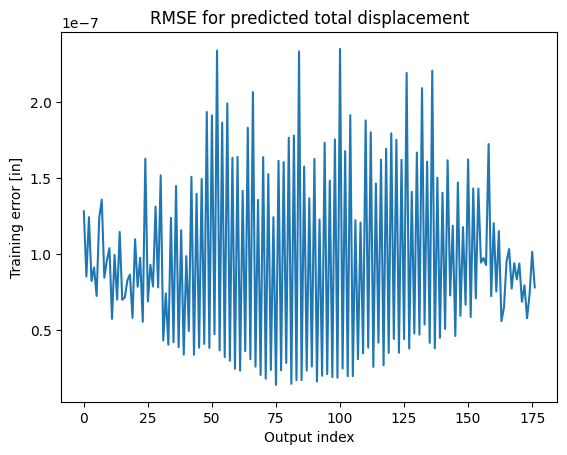

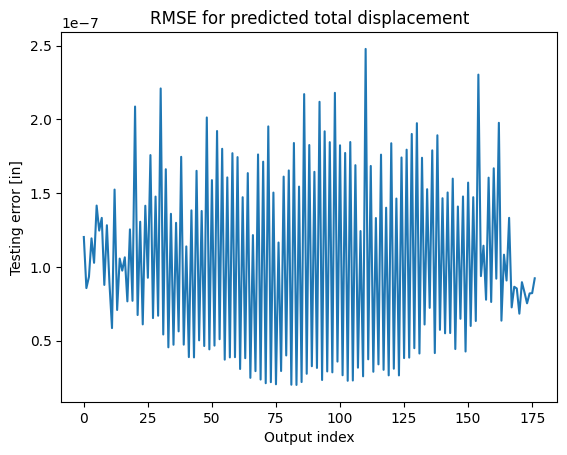

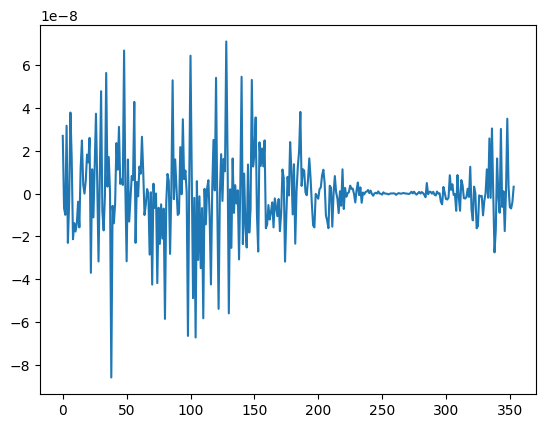

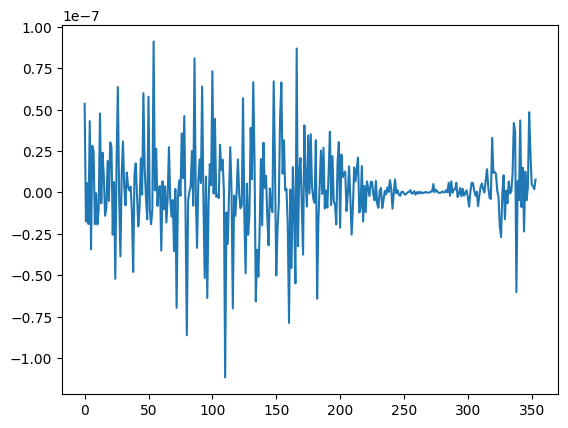

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import sklearn.metrics as metrics

from joblib import dump, load
# reg = load('surrogate_likeDu_v22.joblib')
reg = linear_model.LinearRegression()

scores = cross_val_score(reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(scores)

reg.fit(X_train, y_train)

# Get training error
yhat_train = reg.predict(X_train)
ytotal_train = np.sqrt(np.square(y_train[:,:177]) + np.square(y_train[:,177:]))
yhat_total_train = np.sqrt(np.square(yhat_train[:,:177]) + np.square(yhat_train[:,177:]))
totalTE = ytotal_train - yhat_total_train
print('Training error (total deformation =', np.linalg.norm(totalTE))

RMSETP = np.sqrt(np.sum(abs(np.square(totalTE)), axis=0))
fig = plt.subplots()
plt.plot(RMSETP)
plt.title('RMSE for predicted total displacement')
plt.xlabel('Output index')
plt.ylabel('Training error [in]')
plt.show


# Get test error
yhat_test = reg.predict(X_test)
ytotal_test = np.sqrt(np.square(y_test[:,:177]) + np.square(y_test[:,177:]))
yhat_total_test = np.sqrt(np.square(yhat_test[:,:177]) + np.square(yhat_test[:,177:]))
totalTE = ytotal_test - yhat_total_test
print('Testing error (total deformation =', np.linalg.norm(totalTE))

RMSETP = np.sqrt(np.sum(abs(np.square(totalTE)), axis=0))
fig = plt.subplots()
plt.plot(RMSETP)
plt.title('RMSE for predicted total displacement')
plt.xlabel('Output index')
plt.ylabel('Testing error [in]')
plt.show

# print('Training error (MAE) =', metrics.mean_absolute_error(y_train, yhat_train))
# print('Testing error (MAE) =', metrics.mean_absolute_error(y_test, yhat_test))
print('Training error (MAE) total displacement =', metrics.mean_absolute_error(ytotal_train, yhat_total_train))
print('Testing error (MAE) total displacement =', metrics.mean_absolute_error(ytotal_test, yhat_total_test))
print('Training $R^2$ =', metrics.r2_score(y_train, yhat_train))
print('Testing $R^2$ =', metrics.r2_score(y_test, yhat_test))
# print(metrics.mean_absolute_percentage_error(y_test, yhat_test))
# print(np.max(abs(y_test - yhat_test)))


for i in range(1,3):
    fig = plt.subplots()
    # plt.stem(yhat_test[i,:], y_test[i,:])
    plt.plot(yhat_test[i,:]-y_test[i,:])
    plt.show()

In [7]:
reg.predict(X_train[0].reshape(1,-1))[:,:177].shape

(1, 177)

In [34]:
reg.predict(X_train[0].reshape(1,-1))[:,177:].shape

array([[-1.60435236e-01,  1.75649668e-01, -1.60389774e-01,
         1.78000520e-01, -1.60262140e-01,  1.80357057e-01,
        -1.60054019e-01,  1.82705626e-01, -1.59768751e-01,
         1.85029760e-01, -1.59410112e-01,  1.27418412e-01,
         1.28209200e-01,  1.32009936e-01,  1.31247222e-01,
         1.33850586e-01,  1.31572786e-01,  1.34370660e-01,
         1.31561481e-01,  1.33523819e-01,  1.31092179e-01,
         1.31223381e-01,  1.30014441e-01,  8.28082516e-02,
         1.01287894e-01,  1.22155639e-01,  1.25576958e-01,
         1.15636261e-01,  1.22099702e-01,  1.08137534e-01,
         1.17838359e-01,  9.99920364e-02,  1.12886008e-01,
         9.14768090e-02,  1.07340314e-01,  3.60125174e-02,
         5.99027608e-02,  7.41489996e-02,  9.48040977e-02,
         6.56554360e-02,  8.79838742e-02,  5.74640065e-02,
         8.09448534e-02,  4.97197753e-02,  7.38245942e-02,
         4.25420936e-02,  6.67719249e-02,  1.00978295e-02,
         2.56582051e-02,  3.01571155e-02,  5.33040351e-0

In [20]:
np.max(totalTE)

1.1544145617214951e-07

In [21]:
print(yhat_total_test)
print(ytotal_test)
ytotal_test.shape

[[0.50353638 0.39721268 0.44074171 ... 0.37609963 0.36831898 0.28517534]
 [0.20092024 0.28883212 0.19458724 ... 0.19362707 0.26844585 0.33514866]
 [0.89272452 0.8474491  0.81921757 ... 0.74533109 0.81681175 0.69075239]
 ...
 [1.5234181  1.31470603 1.34775989 ... 1.17689273 1.24522095 1.25269739]
 [0.17359196 0.04511894 0.13295794 ... 0.06796643 0.04233578 0.03723736]
 [1.04871801 0.91992834 0.89776273 ... 0.76045291 0.87416998 0.88684409]]
[[0.5035364  0.39721267 0.44074169 ... 0.37609962 0.36831898 0.28517536]
 [0.20092023 0.2888321  0.19458725 ... 0.19362706 0.26844586 0.33514866]
 [0.89272449 0.84744911 0.81921757 ... 0.7453311  0.81681172 0.69075239]
 ...
 [1.52341805 1.31470606 1.34775985 ... 1.17689269 1.24522094 1.25269744]
 [0.17359202 0.04511893 0.13295793 ... 0.06796644 0.0423358  0.03723735]
 [1.04871803 0.91992831 0.89776275 ... 0.76045292 0.87417001 0.88684406]]


(20, 177)

Save the model

In [ ]:
from joblib import dump, load
dump(reg, 'surrogate_likeDu_v22.joblib')

Track time to run code

In [ ]:
et= time.time()

print("Time to execute notebook = ", et-st, "seconds")

In [1]:
from joblib import dump, load
import numpy as np

reg = load('surrogate_likeDu_v22.joblib')

/home/liuj35/anaconda3/envs/quan/lib/python3.8/site-packages/sklearn/base.py:288: UserWarning: Trying to unpickle estimator LinearRegression from version 1.1.1 when using version 1.2.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
ff = np.random.rand(3,18)
displacements = reg.predict(ff)
u = displacements.flatten()

In [5]:
displacements.shape

array([[-0.00228119, -0.00237487, -0.00245064, ..., -0.00222237,
         0.00205022, -0.00222319],
       [-0.0045757 , -0.00342448, -0.00429729, ..., -0.00058521,
        -0.00034366, -0.00058019],
       [-0.00095906, -0.0018213 , -0.0013218 , ..., -0.00230448,
         0.00221165, -0.00230517]])